# Alarm calls

Focused exploration of `event_type == "alarm"` across all dates.

Reuses the same parquet cache as `explore_calls.ipynb`. The first three cells (imports, helpers, config) mirror that notebook so concepts transfer; the rest is alarm-specific.


## Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PARQUET_DIR = Path("/Users/gilyginosar/Dropbox (Personal)/Vocalizations_project/Data/parquet_cache")

FIGURES_DIR = Path("/Users/gilyginosar/Dropbox (Personal)/Vocalizations_project/Figures/alarm")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    fig.savefig(FIGURES_DIR / f"{name}.pdf", bbox_inches="tight")



In [2]:
# Shared analysis settings — change here, every plotting cell picks them up.
DATES_TO_PLOT = ["2024_12", "2025_03", "2025_07", "2025_10", "2026_02"]
DAYS_PER_DATE = None   # int = keep first N days; None = use all days
N = 10              # minutes per bin
LIGHT_DEFAULT = (8, 20)
LIGHT_OVERRIDES = {"2026_02": (4, 16)}


## Load and filter

Load every date, trim to the first `DAYS_PER_DATE` days, keep only alarm calls. The result is one combined DataFrame `alarm` with a `date_folder` column for provenance.


In [3]:
parts = []
for date_tag in DATES_TO_PLOT:
    df_d = pd.read_parquet(PARQUET_DIR / f"all_calls_{date_tag}.parquet")
    if DAYS_PER_DATE is not None:
        df_d = df_d[df_d["day_in_experiment"] <= DAYS_PER_DATE]
    df_d = df_d[df_d["event_type"] == "alarm"]
    parts.append(df_d)

alarm = pd.concat(parts, ignore_index=True)
print(f"{len(alarm):,} alarm calls across {len(DATES_TO_PLOT)} dates")
alarm.head()


23,994 alarm calls across 5 dates


,exp,file_num,event_type,start_time_file_sec,stop_time_file_sec,duration_sec,assigned_location,channel,meanprob_noise,meanprob_alarm,meanprob_high_freq,meanprob_newborn,meanprob_stacks,meanprob_warble,start_time_experiment_sec,stop_time_experiment_sec,start_time_real,stop_time_real,date_folder,day_in_experiment
0,97,1,alarm,208.662528,208.700544,0.038016,arena_2,20,0.000000,0.833333,0.091540,0.007576,0.014783,0.001473,568.662528,568.700544,2024-12-10 13:25:32.662528,2024-12-10 13:25:32.700544,2024_12,1
1,97,2,alarm,271.253632,271.277056,0.023424,arena_2,20,0.000000,0.834486,0.119877,0.000000,0.000342,0.000000,991.253632,991.277056,2024-12-10 13:32:35.253632,2024-12-10 13:32:35.277056,2024_12,1
2,97,4,alarm,65.151104,65.230336,0.079232,arena_2,20,0.020194,0.819158,0.126401,0.003420,0.003547,0.009472,1505.151104,1505.230336,2024-12-10 13:41:09.151104,2024-12-10 13:41:09.230336,2024_12,1
3,97,4,alarm,288.312704,288.458240,0.145536,arena_2,20,0.000000,0.920295,0.034521,0.004439,0.015584,0.000165,1728.312704,1728.458240,2024-12-10 13:44:52.312704,2024-12-10 13:44:52.458240,2024_12,1
4,97,4,alarm,288.324224,288.467328,0.143104,arena_1,10,0.000000,0.788818,0.180428,0.000734,0.002558,0.010342,1728.324224,1728.467328,2024-12-10 13:44:52.324224,2024-12-10 13:44:52.467328,2024_12,1


## How many alarm calls per date and per location?

In [6]:
# Aggregate the arenas as before so we have just (arena, underground).
alarm = alarm.copy()
alarm["location"] = alarm["assigned_location"].replace({"arena_1": "arena", "arena_2": "arena"})

alarm.groupby(["date_folder", "location"]).size().unstack(fill_value=0)


location,arena,underground
date_folder,,
2024_12,374,60
2025_03,764,3536
2025_07,872,4168
2025_10,1035,8650
2026_02,948,3587


## Time-of-day distribution of alarm calls

Same recipe as in `explore_calls.ipynb`, but only on alarm rows. Useful as a sanity check before going deeper.


In [ ]:
fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(12, 2.5 * len(DATES_TO_PLOT)),
    sharex=True,
    sharey=True,
)

for ax, date_tag in zip(axes, DATES_TO_PLOT):
    df_d = alarm[alarm["date_folder"] == date_tag]
    if df_d.empty:
        ax.text(0.5, 0.5, "no alarm calls", ha="center", va="center", transform=ax.transAxes)
        continue

    ts = df_d["start_time_real"]
    day  = ts.dt.normalize().rename("day")
    slot = (((ts.dt.hour * 60 + ts.dt.minute) // N) * N).rename("slot")

    counts = df_d.groupby([day, slot]).size()
    matrix = counts.unstack(fill_value=0)
    mean = matrix.mean(axis=0)
    std  = matrix.std(axis=0)

    x_hours = mean.index / 60
    ax.plot(x_hours, mean, color="#E63946", label="mean")
    ax.fill_between(x_hours, mean - std, mean + std, alpha=0.2, color="#E63946", linewidth=0)

    light_start, light_end = LIGHT_OVERRIDES.get(date_tag, LIGHT_DEFAULT)
    if light_start < light_end:
        ax.axvspan(0, light_start, color="lightgray", alpha=0.3, zorder=0)
        ax.axvspan(light_end, 24, color="lightgray", alpha=0.3, zorder=0)
    else:
        ax.axvspan(light_end, light_start, color="lightgray", alpha=0.3, zorder=0)

    n_days = matrix.shape[0]
    ax.set_title(f"{date_tag}  (n_days={n_days}, light {light_start:02d}:00-{light_end:02d}:00)", loc="left")
    ax.set_ylabel(f"Alarm calls per {N}-min bin")
    ax.set_xlim(0, 24)

ticks = range(0, 25, 2)
axes[-1].set_xticks(ticks)
axes[-1].set_xticklabels([f"{h:02d}:00" for h in ticks])
axes[-1].set_xlabel("Time of day")

fig.tight_layout()
save_fig(fig, "alarm_per_bin_time_of_day")
plt.show()


## Your turn

Now we're set up to ask the actual interesting questions. Pick one:

- **Burstiness.** Alarm calls might come in clusters (one alarm triggers more). Look at the distribution of inter-call intervals between consecutive alarms in one location. If it's heavy-tailed at short intervals, that's burstiness.

- **Co-occurrence with other calls.** What other call types happen in a small window (say ±10 s) around an alarm? Reuse the full `df_d` (not just alarm) to look at events near each alarm timestamp.

- **Per-experiment differences.** Some experiments may be much more alarm-prone than others. `alarm.groupby(["date_folder", "exp"]).size()` gives the per-experiment count.

- **Confidence filtering.** Plot the distribution of `meanprob_alarm` for these calls. If a lot are below some threshold (say 0.5), the analysis is mixing in low-confidence detections — re-do everything with `alarm[alarm["meanprob_alarm"] > 0.7]` and see if patterns hold.

- **Arena vs underground separately.** The cell above pools both. Try splitting the time-of-day plot by `location`.


## Bouts: detection

A *bout* is a run of alarm calls where each silent gap is below `ICI_BOUT_THRESHOLD_S`. Silent gap = `next.start_time - this.stop_time` (matching `calc_transitions.py`). Grouped by `(date_folder, exp, assigned_location)` so bouts don't span recording restarts (`exp`) or different enclosures.

In [4]:
ICI_BOUT_THRESHOLD_S = 3.0   # silent gap up to this counts as same bout

alarm = alarm.sort_values(
    ["date_folder", "exp", "assigned_location", "start_time_real"]
).reset_index(drop=True)

# Silent gap = this.start_time - previous.stop_time, within each
# (date_folder, exp, assigned_location) group. Matches calc_transitions.py.
group_cols = ["date_folder", "exp", "assigned_location"]
prev_stop = alarm.groupby(group_cols)["stop_time_real"].shift(1)
gaps = alarm["start_time_real"] - prev_stop

is_new_bout = gaps.isna() | (gaps > pd.Timedelta(seconds=ICI_BOUT_THRESHOLD_S))
alarm["bout_id"]   = is_new_bout.cumsum()
alarm["bout_size"] = alarm.groupby("bout_id")["bout_id"].transform("size")

print(f"{alarm['bout_id'].nunique():,} bouts total")
print(f"{(alarm['bout_size'] > 1).sum():,} alarm calls in multi-call bouts "
      f"({(alarm['bout_size'] > 1).mean()*100:.1f}%)")


7,229 bouts total
19,447 alarm calls in multi-call bouts (81.0%)


## Bouts: summary

In [5]:
bouts = alarm.groupby("bout_id").agg(
    date_folder=("date_folder", "first"),
    location=("assigned_location", "first"),
    n_calls=("bout_id", "size"),
    start=("start_time_real", "min"),
    end=("start_time_real", "max"),
)
bouts["duration_s"] = (bouts["end"] - bouts["start"]).dt.total_seconds()

print("Bouts per date_folder:")
print(bouts.groupby("date_folder")["n_calls"].agg(["count", "max", "median"]))
print()
print("Bout-size distribution (all dates pooled):")
print(bouts["n_calls"].value_counts().sort_index().head(15))


Bouts per date_folder:
             count  max  median
date_folder                    
2024_12        221   36     1.0
2025_03        662  293     2.0
2025_07       2174   74     1.0
2025_10       2399  268     1.0
2026_02       1773   77     1.0

Bout-size distribution (all dates pooled):
n_calls
1     4547
2     1136
3      416
4      226
5      142
6      106
7       81
8       70
9       58
10      35
11      43
12      32
13      26
14      26
15      19
Name: count, dtype: int64


## Bout-size distribution (log-log)

### Same, split by date_folder

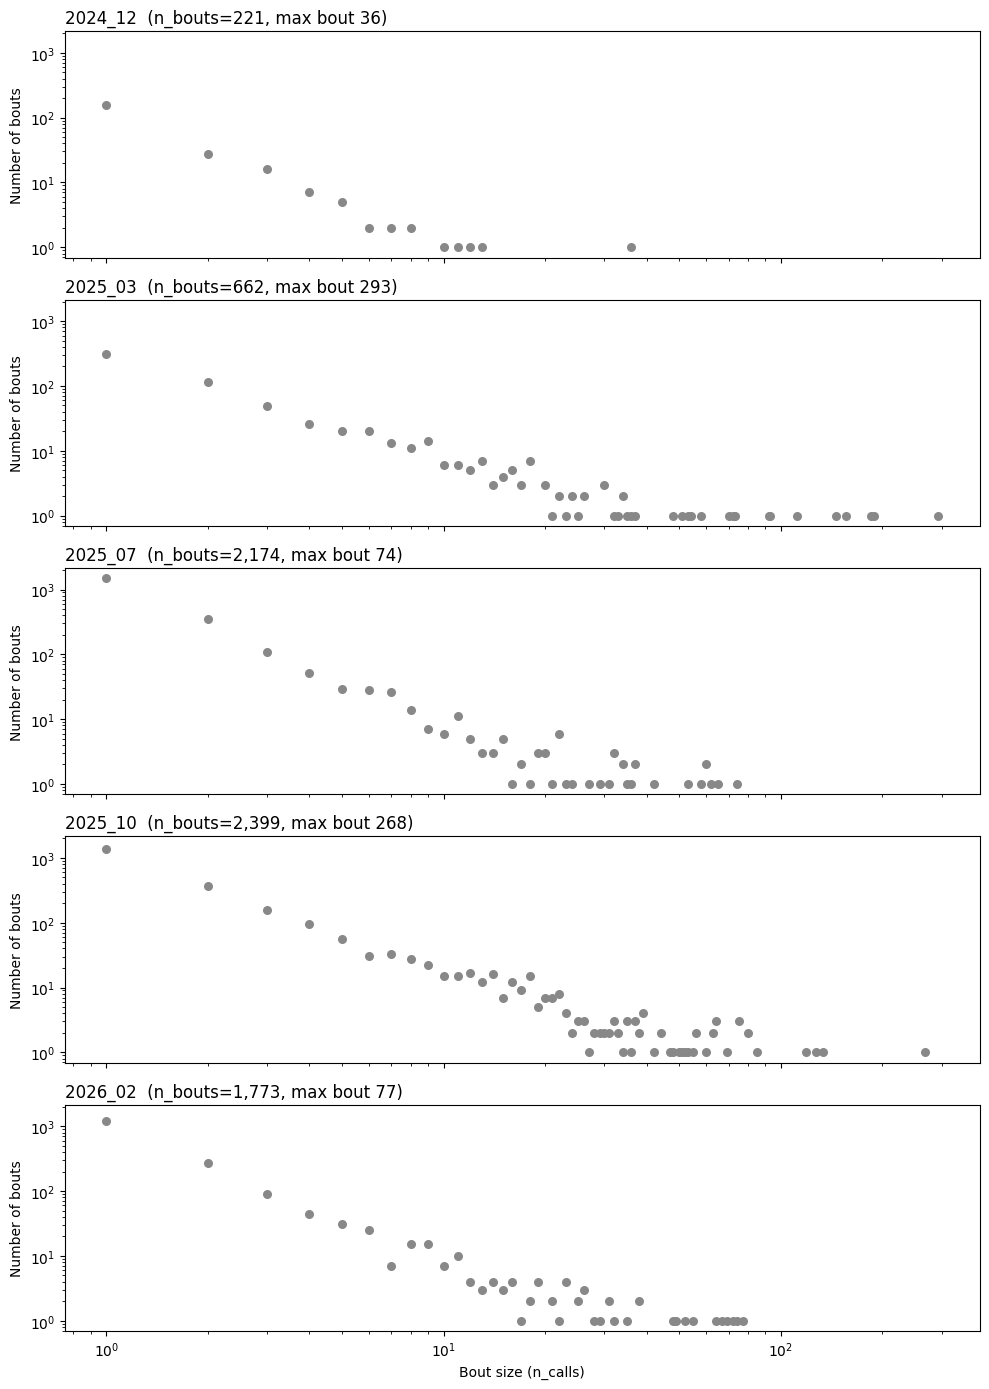

In [22]:
fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(10, 2.8 * len(DATES_TO_PLOT)),
    sharex=True,
    sharey=True,
)

for ax, date_tag in zip(axes, DATES_TO_PLOT):
    sub = bouts[bouts["date_folder"] == date_tag]
    sizes = sub["n_calls"].value_counts().sort_index()

    ax.scatter(sizes.index, sizes.values, color="#888888", s=30)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"{date_tag}  (n_bouts={len(sub):,}, max bout {sub['n_calls'].max()})",
                 loc="left")
    ax.set_ylabel("Number of bouts")

axes[-1].set_xlabel("Bout size (n_calls)")
fig.tight_layout()
save_fig(fig, "alarm_bout_size_distribution_per_date")
plt.show()


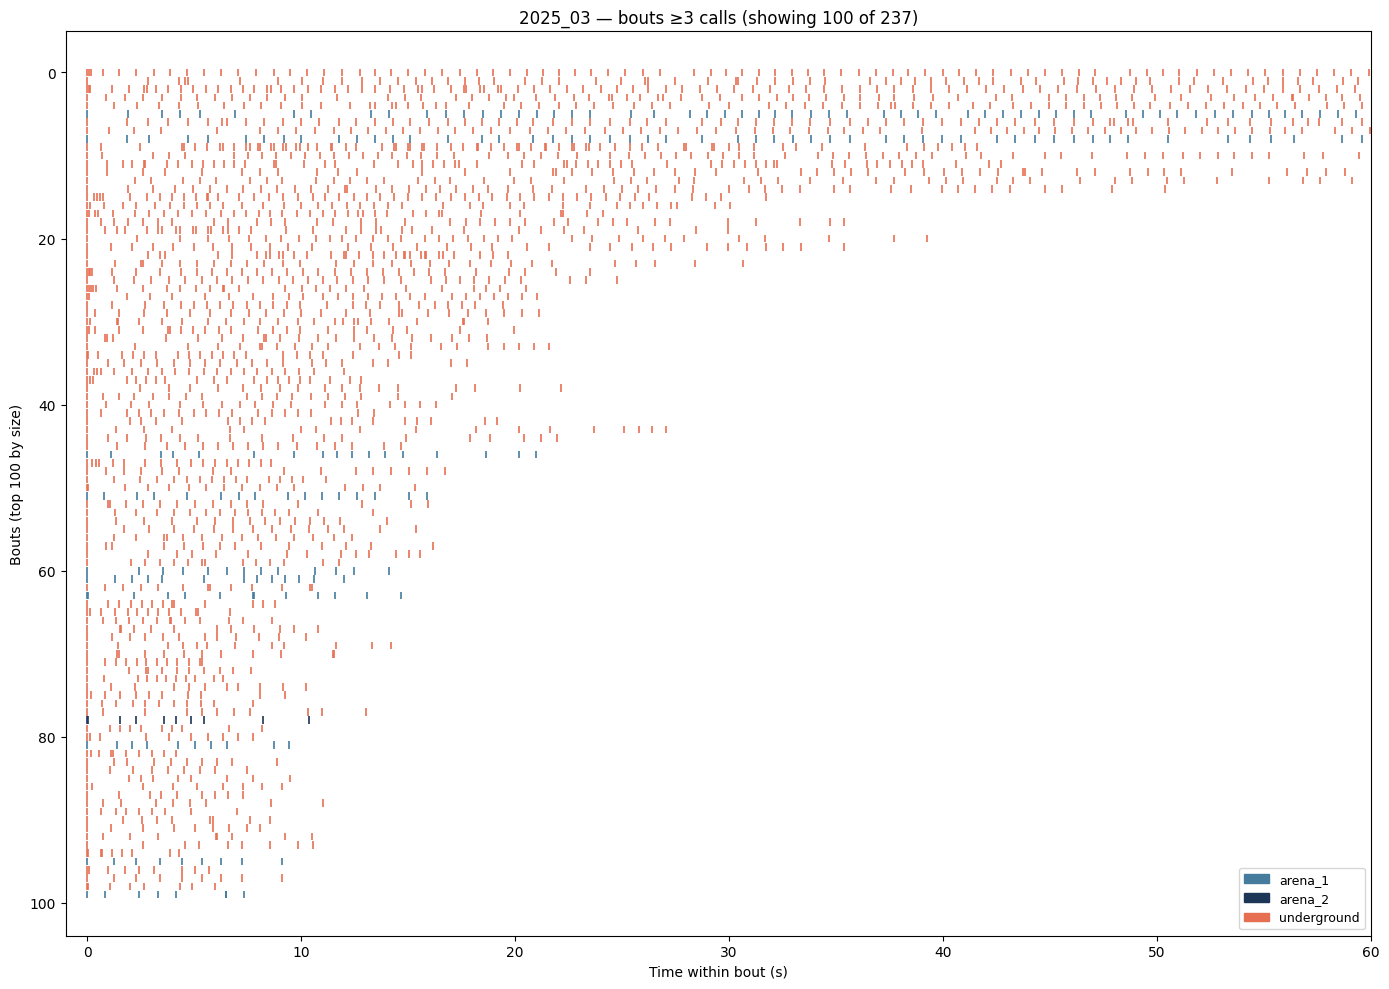

In [11]:
date_tag = "2025_03"
MIN_BOUT_SIZE = 3     # higher threshold → fewer rows → faster
TOP_N = 100           # hard cap on rows shown

mask = (alarm["date_folder"] == date_tag) & (alarm["bout_size"] >= MIN_BOUT_SIZE)
sub = alarm[mask].copy()
if sub.empty:
    raise ValueError(f"No bouts of size >= {MIN_BOUT_SIZE} in {date_tag}")

bout_start = sub.groupby("bout_id")["start_time_real"].transform("min")
sub["t_in_bout_s"] = (sub["start_time_real"] - bout_start).dt.total_seconds()

per_bout = (
    sub.groupby("bout_id")
       .agg(size=("bout_size", "first"), location=("assigned_location", "first"))
       .sort_values("size", ascending=False)
       .head(TOP_N)
)

# Single-pass: assemble a flat (x, y, color) DataFrame for one scatter call.
df_plot = sub[sub["bout_id"].isin(per_bout.index)].copy()
y_map = {bid: i for i, bid in enumerate(per_bout.index)}
df_plot["y"] = df_plot["bout_id"].map(y_map)

loc_colors_map = {"arena_1": "#457B9D", "arena_2": "#1D3557", "underground": "#E76F51"}
df_plot["color"] = df_plot["assigned_location"].map(loc_colors_map)

height = min(max(3, len(per_bout) * 0.1), 20)
fig, ax = plt.subplots(figsize=(14, height))
ax.scatter(df_plot["t_in_bout_s"], df_plot["y"],
           c=df_plot["color"], marker="|", s=30, linewidth=1.2)
ax.invert_yaxis()
ax.set_xlim(-1, 60)
ax.set_xlabel("Time within bout (s)")
ax.set_ylabel(f"Bouts (top {len(per_bout)} by size)")
ax.set_title(
    f"{date_tag} — bouts ≥{MIN_BOUT_SIZE} calls "
    f"(showing {len(per_bout)} of {sub['bout_id'].nunique():,})"
)

from matplotlib.patches import Patch
handles = [Patch(color=c, label=loc) for loc, c in loc_colors_map.items()]
ax.legend(handles=handles, loc="lower right", fontsize=9)

fig.tight_layout()
fig.savefig(FIGURES_DIR / f"alarm_bouts_raster_{date_tag}_min{MIN_BOUT_SIZE}.png",
            dpi=120, bbox_inches="tight")
plt.show()
